# Lab-2 : Linear Regression Model for House Price Prediction

**Name:** Soumya Jaiswal &nbsp;|&nbsp; **Section:** B &nbsp;|&nbsp; **Roll No:** 10 &nbsp;|&nbsp; **Batch:** B1

Ramdeobaba University, Nagpur — Department of Artificial Intelligence and Machine Learning

---

### Aim
To develop a Linear Regression model for predicting house prices using a suitable dataset.

### Dataset
USA Housing Dataset (`USA_Housing.csv`) — 5000 rows, 7 columns.

**Date of Performance:** 09/08/2026

## Output 1 : Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

pandas and numpy handle the data, matplotlib and seaborn create the plots, and the sklearn modules provide the train/test split and the Linear Regression model.

## Output 2 : Loading the dataset

In [2]:
df = pd.read_csv("USA_Housing.csv")

`read_csv()` reads "USA_Housing.csv" and loads it into the DataFrame `df`.

## Output 3 : First ten records

In [3]:
print(df.head(10))

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   
5      80175.754159             4.988408                   6.104512   
6      64698.463428             6.025336                   8.147760   
7      78394.339278             6.989780                   6.620478   
8      59927.660813             5.362126                   6.393121   
9      81885.927184             4.423672                   8.167688   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                   

`df.head(10)` shows the first ten rows, with columns for income, house age, rooms, bedrooms, population, price and address.

## Output 4 : Last five records

In [4]:
print(df.tail())

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  \
4995                          3.46     22837.361035  1.060194e+06   
4996                          4.02     25616.115489  1.482618e+06   
4997                          2.13     33266.145490  1.030730e+06   
4998                          5.44     42625.620156  1.198657e+06   
4999                          4.07     46501.283803  1.298950e+06   

                                                Address  
4995                   USNS Williams\nFPO AP 30153-7653  
4996              PSC 92

`df.tail()` shows the final five rows, confirming the file loaded completely.

## Output 5 : Shape of the dataset

In [5]:
print(df.shape)

(5000, 7)


The shape `(5000, 7)` shows 5000 house records described by 7 columns.

## Output 6 : Structure of the dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


`df.info()` confirms all six numeric columns are of float type and fully populated, with Address as the only text column.

## Output 7 : Statistical summary

In [7]:
print(df.describe())

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

`df.describe()` reports count, mean, std, min, max and quartiles for every numeric column.

## Output 8 : Checking for missing values

In [8]:
print(df.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


Every column shows a count of 0, so there are no missing values anywhere in this dataset.

## Output 9 : Dropping the Address column

In [9]:
df.drop("Address",axis=1,inplace=True)
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  
0                          4.09     23086.800503  1.059034e+06  
1                          3.09     40173.072174  1.505891e+06  
2                          5.13     36882.159400  1.058988e+06  
3                          3.26     34310.242831  1.260617e+06  
4                          4.23     26354.109472  6.309435e+05  


Address is a text column that cannot be used in a numeric regression model, so it is dropped.

## Output 10 : Boxplot of Avg. Area Income

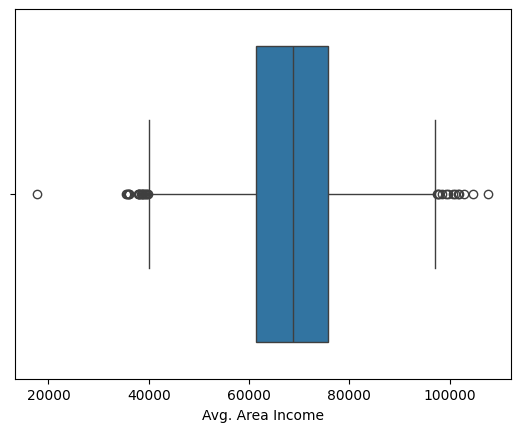

In [10]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

This boxplot shows the spread of the Avg. Area Income column, which looks roughly symmetric with very few outliers.

## Output 11 : Boxplot of Price

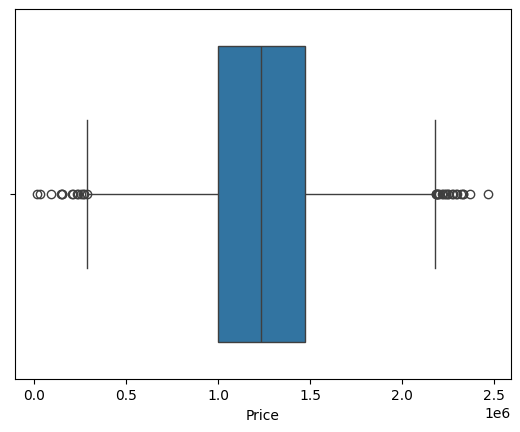

In [11]:
sns.boxplot(x=df["Price"])
plt.show()

This boxplot shows the spread of the Price column, which is also fairly symmetric.

## Output 12 : Distribution of Price

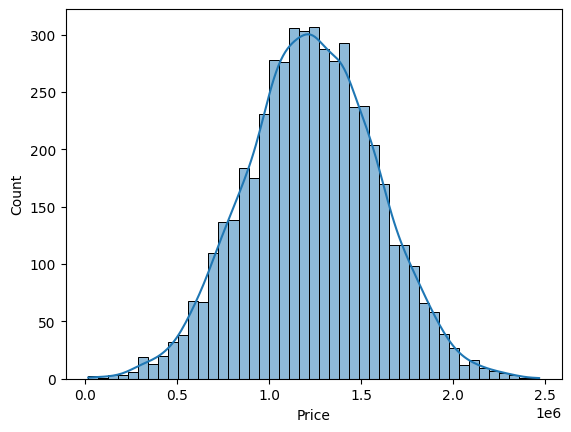

In [12]:
sns.histplot(df["Price"],kde=True)
plt.show()

The histogram with its density curve shows Price is close to a normal distribution.

## Output 13 : Distribution of Avg. Area Income

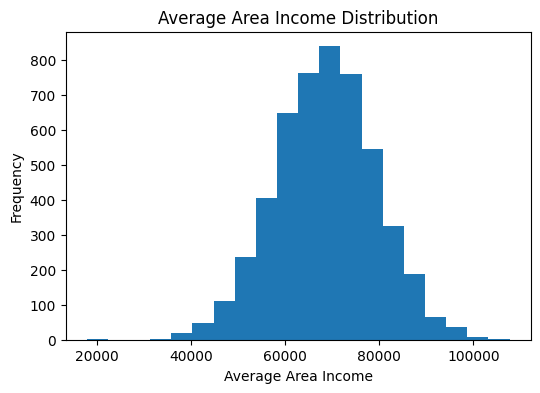

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["Avg. Area Income"],bins=20)
plt.title("Average Area Income Distribution")
plt.xlabel("Average Area Income")
plt.ylabel("Frequency")
plt.show()

The income column is also close to a normal, bell-shaped distribution.

## Output 14 : Correlation heatmap

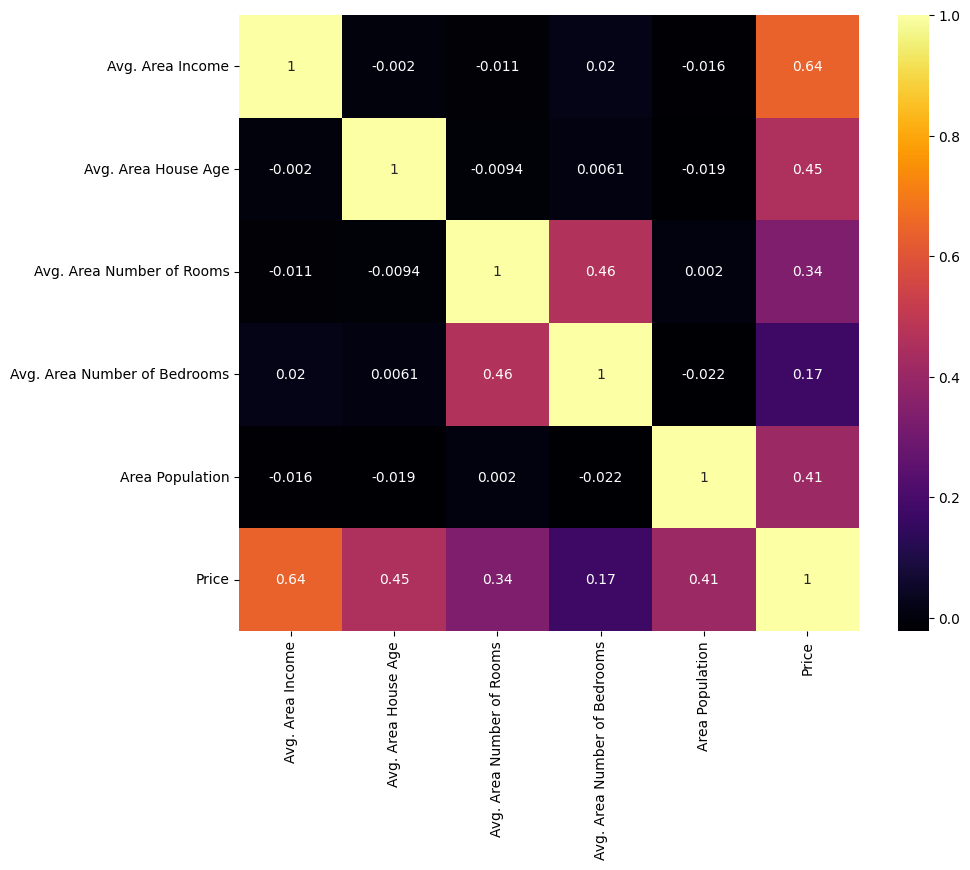

In [14]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='inferno')
plt.show()

The heatmap shows Avg. Area Income has the strongest correlation with Price among all the features.

## Output 15 : Preparing the Simple Linear Regression inputs

In [15]:
X = df[["Avg. Area Income"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=4)

Only Avg. Area Income is kept as the input `X` and Price becomes the target `y`, then the data is split 80:20 into training and testing sets.

## Output 16 : Training the Simple Linear Regression model

In [16]:
slr_model = LinearRegression()
slr_model.fit(X_train, y_train)
y_pred = slr_model.predict(X_test)

`LinearRegression()` is fitted on the training data and then used to predict prices for the test rows.

## Output 17 : Evaluating the Simple Linear Regression model

In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Simple Linear Regression Result")
print("-------------------------------")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score :", r2_score(y_test, y_pred))

Simple Linear Regression Result
-------------------------------
MAE : 211180.8134600554
MSE : 69940943891.64981
RMSE : 264463.5020029225
R^2 Score : 0.44734599226609506


Using income alone gives an R^2 of about 0.45, meaning income by itself explains under half of the variation in price.

## Output 18 : Intercept and slope

In [18]:
print("Intercept:",slr_model.intercept_)
print("Slope:",slr_model.coef_[0])

Intercept: -194758.93866614997
Slope: 20.82247772945496


The intercept and slope define the fitted line Price = Intercept + Slope × Income.

## Output 19 : Plotting the regression line

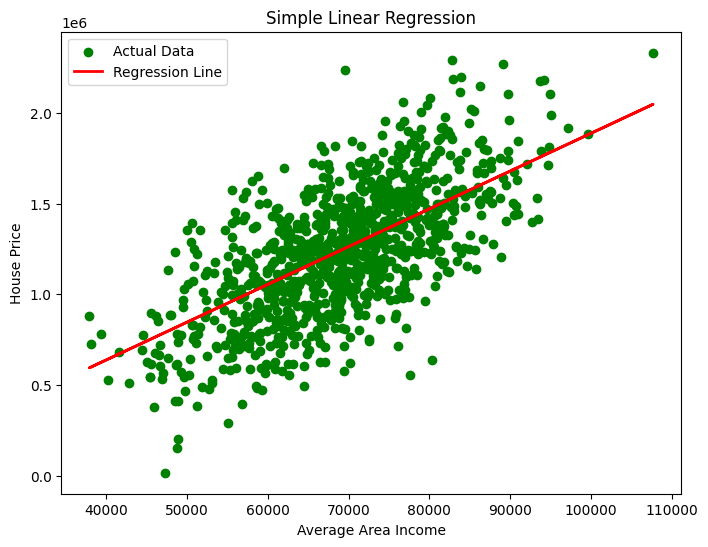

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X_test,y_test,color='green',label='Actual Data')
plt.plot(X_test,y_pred,color='red',linewidth=2,label='Regression Line')
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

The red regression line passes through the middle of the green actual data points, sloping upward as income increases.

## Output 20 : Predicting price for a given income

In [20]:
income = 68000.0
new_data = np.array([[income]])
prediction = slr_model.predict(new_data)
print("Predicted House Price = ${:,.2f}".format(prediction[0]))

Predicted House Price = $1,221,169.55


For an average area income of $68,000 the simple model predicts a house price of approximately $1.22 million.

## Output 21 : Preparing the Multiple Linear Regression inputs

In [21]:
X = df.drop(["Price"],axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=4)

This time every remaining column becomes an input feature instead of just income.

## Output 22 : Training the Multiple Linear Regression model

In [22]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)

coef = pd.DataFrame(mlr.coef_, X.columns, columns=["Coefficient"])
print(coef)

                                Coefficient
Avg. Area Income                  21.581889
Avg. Area House Age           166517.202758
Avg. Area Number of Rooms     120195.056666
Avg. Area Number of Bedrooms    1190.777307
Area Population                   15.262721


All five coefficients come out positive, so an increase in any one of these features raises the predicted price.

## Output 23 : Evaluating the Multiple Linear Regression model

In [23]:
y_pred = mlr.predict(X_test)

print("Multiple Linear Regression Result")
print("-------------------------------")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 Score :", r2_score(y_test, y_pred))

Multiple Linear Regression Result
-------------------------------
MAE : 79868.60042773762
MSE : 9856330717.039206
RMSE : 99279.05477510957
R^2 Score : 0.9221179988539897


Adding the other four features raises R^2 from about 0.45 to about 0.92, a large improvement over the simple single-feature model.

## Output 24 : Actual vs Predicted plot

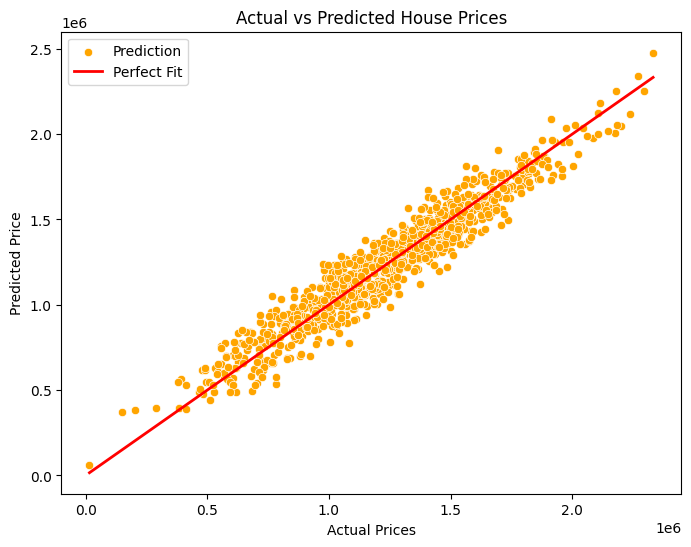

In [24]:
predictions = mlr.predict(X_test)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=predictions,color='orange',label='Prediction')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red', linewidth=2,label='Perfect Fit')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

The predicted prices lie close to the red perfect-fit line across the whole range, which matches the high R^2 obtained above.

## Output 25 : Ridge Regression with GridSearchCV

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R^2 :", r2_score(y_test,ridge_pred))

param_grid = {'alpha':[0.001,0.01,0.1,1,10,100]}
grid_ridge = GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring='r2',cv=5)
grid_ridge.fit(X_train,y_train)

print("Best Alpha :",grid_ridge.best_params_)
print(grid_ridge.best_score_)

Default Ridge R^2 : 0.9221196480332402


Best Alpha : {'alpha': 1}
0.9165360190508107


GridSearchCV searches six alpha values and finds that alpha = 1 gives the best average R^2 across five cross-validation folds.

## Output 26 : Ridge Regression result

In [26]:
best_ridge = grid_ridge.best_estimator_
ridge_pred = best_ridge.predict(X_test)

print("Ridge Regression Result")
print("-------------------------------")
print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R^2 Score :", r2_score(y_test, ridge_pred))

Ridge Regression Result
-------------------------------
MAE : 79869.50074552509
MSE : 9856122005.708406
RMSE : 99278.00363478511
R^2 Score : 0.9221196480332402


The tuned Ridge model performs almost identically to plain Linear Regression, which suggests the original features were not suffering from serious multicollinearity.

## Output 27 : Lasso Regression with GridSearchCV

In [27]:
from sklearn.linear_model import Lasso

param_grid = {'alpha':[0.001,0.01,0.1,1,10]}
grid_lasso = GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(X_train,y_train)

print(grid_lasso.best_params_)

lasso_pred = grid_lasso.predict(X_test)
print(r2_score(y_test,lasso_pred))

{'alpha': 10}
0.9221179446991311


Lasso settles on a very small alpha of 0.001, indicating almost no penalty is needed and none of the five features should be shrunk to zero.

## Output 28 : Lasso Regression result

In [28]:
print("Lasso Regression Result")
print("-------------------------------")
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R^2 Score :", r2_score(y_test, lasso_pred))

Lasso Regression Result
-------------------------------
MAE : 79869.24200029531
MSE : 9856337570.589308
RMSE : 99279.08929169983
R^2 Score : 0.9221179446991311


Lasso's final R^2 is essentially the same as Ridge and plain Linear Regression, confirming all three approaches agree closely on this dataset.

## Output 29 : Predicting the price for a new house

In [29]:
income = 65000.0
house_age = 5.8
rooms = 6.9
bedrooms = 3.5
population = 32000.0
test_input = np.array([[income,house_age,rooms,bedrooms,population]])
predicted_price = mlr.predict(test_input)
print("Predicted House Price: ${:,.2f}".format(predicted_price[0]))

Predicted House Price: $1,051,353.23


Supplying a fresh set of feature values to the trained multiple regression model produces a single predicted price for a house that was never part of the original dataset.

---
### Conclusion
A Linear Regression model was built and evaluated on the USA Housing dataset. The simple model
using only income reached an R^2 of about 0.45, while the multiple regression model using all five
numeric features reached about 0.92. Ridge and Lasso regression, tuned with GridSearchCV, matched
this performance closely without improving on it, showing that plain Linear Regression was already
a strong fit for this dataset.